# Population Inference

Individual galaxies weakly constrain the PSD timescale τ_PS. A population
sharing the same burstiness physics can break this degeneracy. **No other
SED-fitting code does this.**

**The hierarchical model**: shared hyperparameters ϕ = (σ_PS, τ_PS) govern
the burstiness prior for every galaxy. Per-galaxy latent variables include
the GP field ξ_i (64 dims) and physical parameters θ_i (7 dims). Hierarchical
inference (MGVI) pools information about the shared PSD hyperparameters,
dramatically tightening τ_PS as N grows.

**What you'll see**: shared posterior on σ_PS and τ_PS narrows from N=5 to
N=30 galaxies as 1/√N — the Bayesian central-limit theorem. Spectroscopy
breaks the σ–τ degeneracy that photometry alone cannot.

**Prerequisites**: [`02_sfh_gallery.py`](02_sfh_gallery.py) for PSD theory;
[`08_fitting_spectra.py`](08_fitting_spectra.py) for single-galaxy fitting.

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import hashlib
import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    PopulationFitter,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

import contextlib

# Pre-warm nifty8 import to avoid _DeadlockError when running VI in a loop
with contextlib.suppress(Exception):
    import nifty8.re.evi

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "population")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

# Gate expensive sections (√N scaling, population distinction)
RUN_EXPENSIVE = False

W0423 02:15:23.150205 23172134 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [2]:
# Load SSP data and define observation
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
N_PIX = len(WAVE_OBS)
FILTER_NAMES = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]

obs = Observation(
    photometry=Photometry.from_names(FILTER_NAMES),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

# True shared PSD parameters. PopulationFitter doesn't accept
# posterior_chunk_size (that lives on Fitter.run), so we keep the lightweight
# model from the memory-tamed configuration: n_grid=32, simplified shape params.
# Flip RUN_EXPENSIVE=True to also execute the heavy spectroscopic hierarchical
# fit; default runs photometry-only.
TRUE_SIGMA = 2.0
TRUE_TAU = 20.0
N_GAL = 10 if RUN_EXPENSIVE else 4
SPEC_SNR = 30.0
PHOT_SNR = 20.0
N_HIER_ITERS = 10 if RUN_EXPENSIVE else 4

In [3]:
# Model factory for hierarchical inference
def model_factory(psd_sigma=1.0, psd_tau_myr=50.0):
    """Create a lightweight SEDModel — called by PopulationFitter."""
    spec = Parameters(
        sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
        sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
        sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
        sfh_tsnorm_skew=Fixed(0.0),
        sfh_tsnorm_trunc=Fixed(3.0),
        sfh_field_psd_sigma=Fixed(psd_sigma),
        sfh_field_psd_tau_myr=Fixed(psd_tau_myr),
        met_logzsol=Uniform(-2.0, 0.2),
        dust_tau_bc=Uniform(0.0, 2.0),
        dust_tau_diff=Fixed(0.3),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.1),
        mean_sfh_type=["tsnorm", "field"],
        n_grid=32,
    )
    return SEDModel(spec, ssp_data, observation=obs)

In [4]:
# Helper: generate mock population with shared PSD
def make_population(n_gal, psd_sigma, psd_tau_myr, seed=42):
    """Generate N mock galaxies with shared PSD hyperparameters.

    Returns:
        dict with keys:
        - 'galaxies_spec': list of {'flux_obs', 'noise'} dicts
        - 'galaxies_phot': list of {'flux_obs', 'noise'} dicts
        - 'true_params': list of parameter dicts
        - 'true_spectra': list of true spectrum arrays (for posterior predictive)
    """
    print(f"Generating {n_gal} mock galaxies with σ_PS = {psd_sigma}, τ_PS = {psd_tau_myr} Myr...")
    key = jax.random.PRNGKey(seed)
    model_gen = model_factory(psd_sigma=psd_sigma, psd_tau_myr=psd_tau_myr)

    galaxies_spec = []
    galaxies_phot = []
    true_params_all = []
    true_spectra = []

    for i in range(n_gal):
        k = jax.random.fold_in(key, i)
        params = model_gen.spec.sample(k)

        # Spectroscopic mock
        mock_s = model_gen.mock_spectrum(
            params, WAVE_OBS, snr=SPEC_SNR, key=jax.random.fold_in(k, 1)
        )
        galaxies_spec.append({"flux_obs": mock_s.flux_obs, "noise": mock_s.noise})
        true_spectra.append(np.array(mock_s.flux_true))

        # Photometric mock
        mock_p = model_gen.mock(params, snr=PHOT_SNR, key=jax.random.fold_in(k, 2))
        galaxies_phot.append({"flux_obs": mock_p.flux_obs, "noise": mock_p.noise})

        true_params_all.append(params)

    print(f"  Per-galaxy: D = {model_gen.spec.n_free} physical + 64 GP")
    print(
        f"  Total (hierarchical): D = {n_gal} x {model_gen.spec.n_free + 64}"
        f" + 2 shared = {n_gal * (model_gen.spec.n_free + 64) + 2}"
    )

    return {
        "galaxies_spec": galaxies_spec,
        "galaxies_phot": galaxies_phot,
        "true_params": true_params_all,
        "true_spectra": true_spectra,
        "model_gen": model_gen,
    }

In [5]:
# Generate population
pop_data = make_population(N_GAL, TRUE_SIGMA, TRUE_TAU, seed=42)
galaxies_spec = pop_data["galaxies_spec"]
galaxies_phot = pop_data["galaxies_phot"]
true_params_all = pop_data["true_params"]
true_spectra = pop_data["true_spectra"]
model_gen = pop_data["model_gen"]

print(f"  Spectroscopy: {N_PIX} pixels, SNR = {SPEC_SNR}")
print(f"  Photometry: {obs.n_data_phot} bands, SNR = {PHOT_SNR}")

Generating 4 mock galaxies with σ_PS = 2.0, τ_PS = 20.0 Myr...


/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:517: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


  Per-galaxy: D = 5 physical + 64 GP
  Total (hierarchical): D = 4 x 69 + 2 shared = 278
  Spectroscopy: 200 pixels, SNR = 30.0
  Photometry: 5 bands, SNR = 20.0


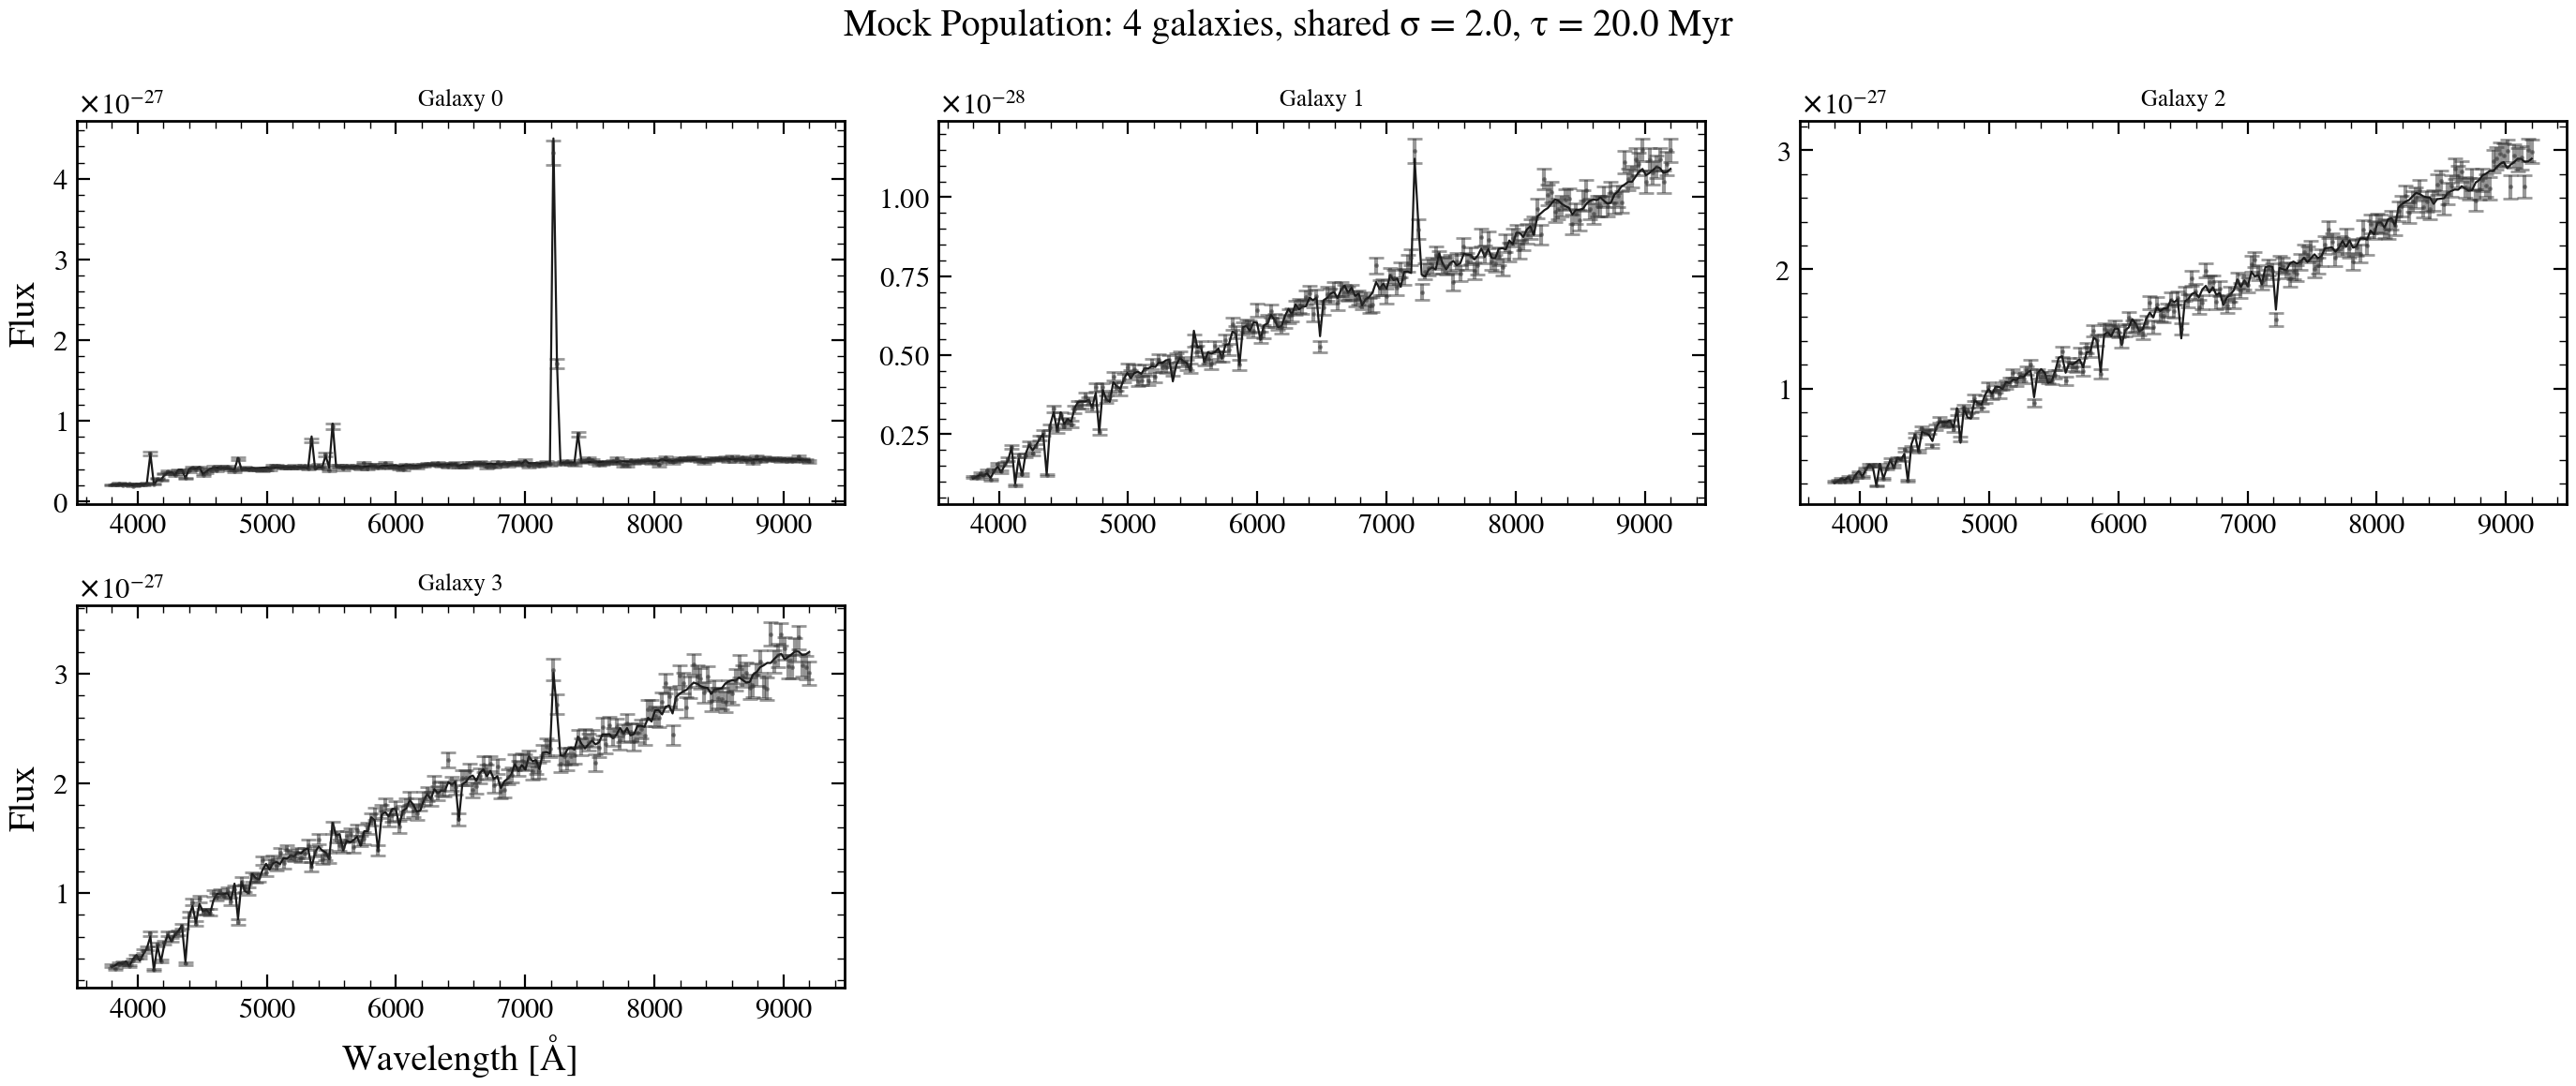

In [6]:
# --- FIGURE 1: Galaxy diversity ---
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i >= min(6, N_GAL):
        ax.set_visible(False)
        continue
    ax.errorbar(
        np.array(WAVE_OBS),
        np.array(galaxies_spec[i]["flux_obs"]),
        yerr=np.array(galaxies_spec[i]["noise"]),
        fmt=".",
        ms=1.5,
        color=COLORS["data"],
        alpha=0.5,
    )
    true_spec = model_gen.predict_spectrum(true_params_all[i])
    ax.plot(np.array(WAVE_OBS), np.array(true_spec), color=COLORS["truth"], lw=0.8)
    ax.set_title(f"Galaxy {i}", fontsize=9)
    if i >= 3:
        ax.set_xlabel("Wavelength [Å]")
    if i % 3 == 0:
        ax.set_ylabel("Flux")
fig.suptitle(f"Mock Population: {N_GAL} galaxies, shared σ = {TRUE_SIGMA}, τ = {TRUE_TAU} Myr")
fig.tight_layout()
plt.show()

## 1. Individual Spectroscopic Fits

First, fit each galaxy independently with PSD parameters **free**.
This establishes the per-galaxy constraining power. σ_PS is roughly
constrained but τ_PS spans much of its prior.

In [7]:
# Helper: fit N galaxies individually with free PSD
def fit_individual_galaxies(galaxies, model, data_type="spectroscopy", n_gal_fit=4):
    """Fit individual galaxies with free PSD parameters.

    Args:
        galaxies: list of {'flux_obs', 'noise'} dicts
        model: SEDModel with free PSD priors
        data_type: 'spectroscopy' or 'photometry'
        n_gal_fit: number of galaxies to fit (default 4)

    Returns:
        list of FitterResult objects
    """
    results = []
    print(f"Fitting {n_gal_fit} galaxies individually (PSD free)...")
    for i in range(min(n_gal_fit, len(galaxies))):
        fitter_i = Fitter(
            model,
            galaxies[i]["flux_obs"],
            galaxies[i]["noise"],
            data_type=data_type,
        )
        t0 = time.perf_counter()
        res_i = fitter_i.run(
            "vi",
            n_iterations=8,
            n_samples=6,
            n_posterior_samples=500,
            verbose=False,
        )
        dt = time.perf_counter() - t0
        results.append(res_i)
        sig_med = float(jnp.median(res_i.samples["sfh_field_psd_sigma"]))
        tau_med = float(jnp.median(res_i.samples["sfh_field_psd_tau_myr"]))
        print(f"  Galaxy {i}: sigma = {sig_med:.2f}, tau = {tau_med:.0f} Myr  ({dt:.1f}s)")
    return results

In [8]:
# Individual fits with FREE PSD
spec_free = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=64,
)
model_free = SEDModel(spec_free, ssp_data, observation=obs)

individual_results = fit_individual_galaxies(
    galaxies_spec, model_free, data_type="spectroscopy", n_gal_fit=4
)

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


Fitting 4 galaxies individually (PSD free)...


/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


OPTIMIZE_KL: Starting 0001


...

MCG: Iteration 6 ⛰:-7.8981e-02 Δ⛰:2.4313e-02 ➽:3.7726e-02 |∇|:9.1441e+01 ➽:8.5263e+01


M: →:1.0 ↺:False #∇²:66 |↘|:7.231153e-02 🞋:7.400000e-04
M: Iteration 10 ⛰:+2.304378e+02 Δ⛰:7.923643e-02 🞋:1.000000e-03


M: Iteration Limit Reached!


OPTIMIZE_KL: Iteration 0008 ⛰:+2.3044e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     1.8±   0.069, avg:    +0.02±   0.065, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     9.1±     4.8, avg:     -2.9±    0.82, #dof:      1'
dust_tau_diff           :: 'reduced χ²:     7.9±     4.3, avg:     -2.7±    0.77, #dof:      1'
met_logzsol             :: 'reduced χ²:     4.3±     3.0, avg:     -1.9±    0.78, #dof:      1'
psd_xi                  :: 'reduced χ²:     1.2±    0.26, avg:   +0.044±   0.086, #dof:     64'
sfh_field_psd_sigma     :: 'reduced χ²:    0.63±    0.93, avg:    +0.28±    0.74, #dof:      1'
sfh_field_psd_tau_myr   :: 'reduced χ²:     1.0±     1.8, avg:    -0.14±     1.0, #dof:      1'
sfh_tsnorm_log_peak_sfr :: 'reduced χ²:    0.33±    0.38, avg:    -0.25±    0.52, #dof:      1'
sfh_tsnorm_peak_lbt_gyr :: '

  Galaxy 3: sigma = 2.17, tau = 137 Myr  (77.4s)


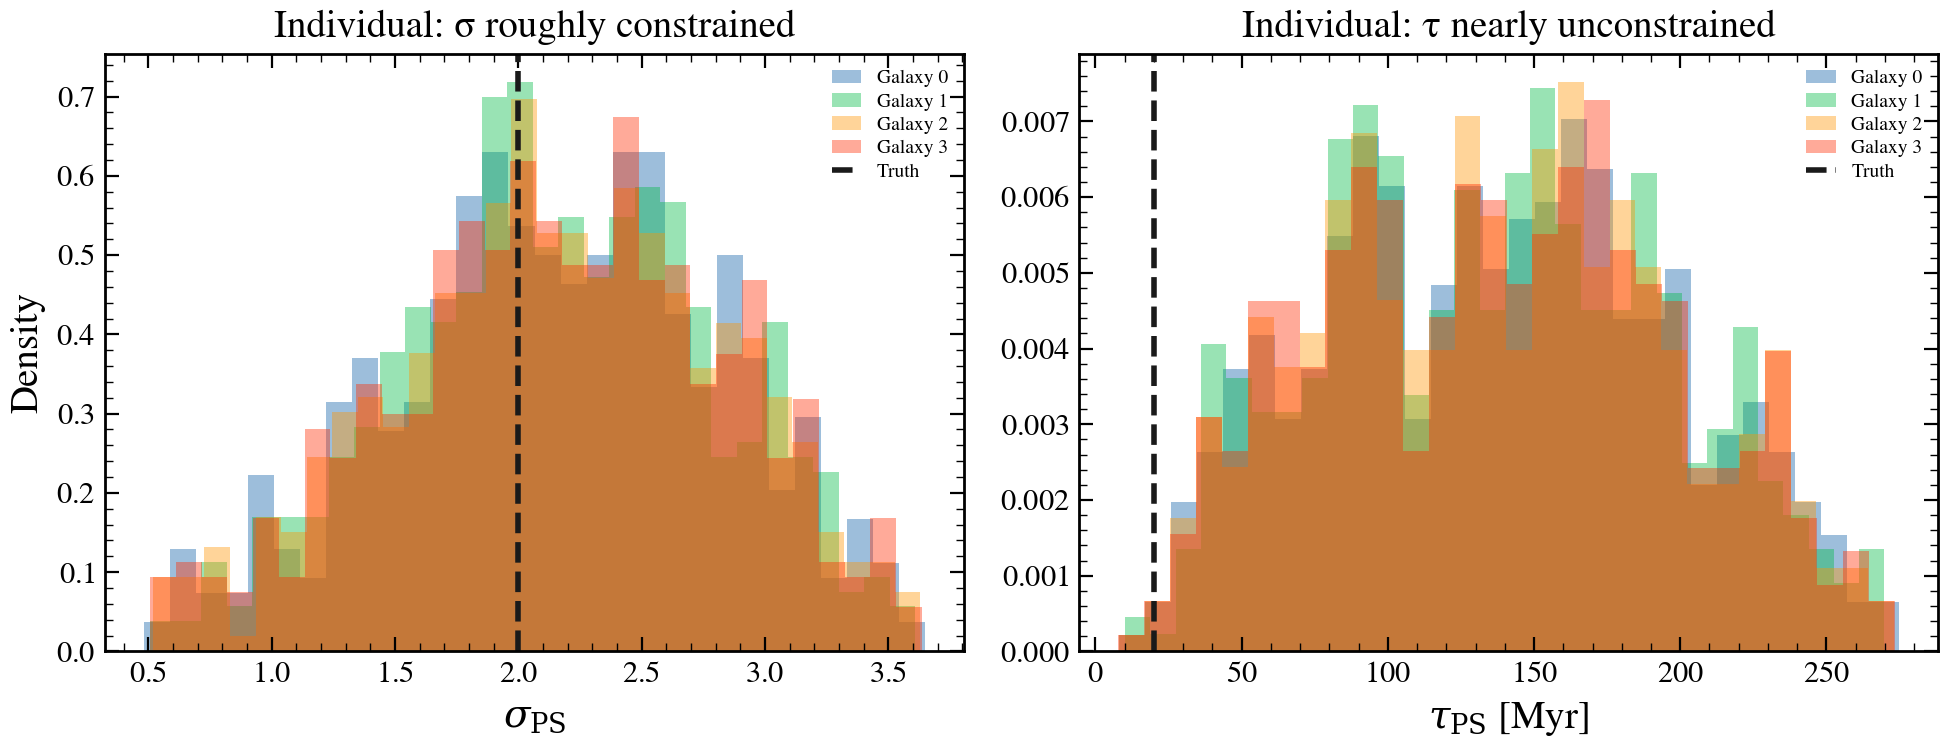

In [9]:
# --- FIGURE 2: Individual PSD posteriors (wide, overlapping) ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(10, 4))
for _i, res in enumerate(individual_results):
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax_sig.hist(sig_s, bins=30, alpha=0.4, density=True, label=f"Galaxy {_i}")
    ax_tau.hist(tau_s, bins=30, alpha=0.4, density=True, label=f"Galaxy {_i}")

ax_sig.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_tau.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_sig.set_xlabel(r"$\sigma_{\rm PS}$")
ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
ax_sig.set_ylabel("Density")
ax_sig.legend(fontsize=7)
ax_tau.legend(fontsize=7)
ax_sig.set_title("Individual: σ roughly constrained")
ax_tau.set_title("Individual: τ nearly unconstrained")
fig.tight_layout()
plt.show()

In [10]:
def _pop_posterior_sigma_tau(pop_posterior):
    """Return (sigma_samples, tau_samples, tau_is_myr) from EVI or CFM posteriors.

    The EVI-JIT backend produces ``psd_sigma``/``psd_tau_myr`` (samples
    directly on the physical grid the mocks were drawn from).

    The CFM backend (CorrelatedFieldMaker, current default via "mgvi")
    produces ``psd_sigma_eff`` (≈ exp of the fluctuations log-amplitude) and
    ``psd_loglogavgslope`` (spectral slope of the GP, dimensionless). The
    slope is *not* τ in Myr — surface it anyway so the figures populate, and
    return tau_is_myr=False so the caller knows to suppress the TRUE_TAU
    truth overlay and relabel the axis.
    """
    s = pop_posterior.shared_samples
    if "psd_sigma" in s and "psd_tau_myr" in s:
        return np.array(s["psd_sigma"]), np.array(s["psd_tau_myr"]), True
    return (
        np.array(s["psd_sigma_eff"]),
        np.array(s["psd_loglogavgslope"]),
        False,
    )

## 2. Hierarchical Inference: Spectroscopy (gated)

The spectroscopic hierarchical fit is the memory-heaviest piece (each galaxy
adds a 200-pixel likelihood to the batched forward map). `PopulationFitter`
doesn't currently forward the `posterior_chunk_size` plumbing, so we gate
this cell behind `RUN_EXPENSIVE = True` at the top of the notebook. The
photometric hierarchical fit in §3 runs unconditionally.

In [11]:
if RUN_EXPENSIVE:
    print(f"\nHierarchical fit: {N_GAL} galaxies (spectroscopy)...")
    t0 = time.perf_counter()
    hfitter_spec = PopulationFitter(
        model_factory,
        galaxies_spec,
        psd_sigma_prior=(0.1, 4.0),
        psd_tau_prior=(1.0, 300.0),
        data_type="spectroscopy",
    )
    result_hier_spec = hfitter_spec.run(
        "mgvi",
        n_iterations=N_HIER_ITERS,
        n_samples=4,
        n_posterior_samples=200,
        verbose=False,
        key=jax.random.PRNGKey(0),
    )
    t_hier_spec = time.perf_counter() - t0

    sig_spec, tau_spec, tau_spec_is_myr = _pop_posterior_sigma_tau(result_hier_spec)
    print(
        f"  σ_PS = {np.median(sig_spec):.2f} [{np.percentile(sig_spec, 16):.2f}, "
        f"{np.percentile(sig_spec, 84):.2f}]"
    )
    print(
        f"  τ_PS = {np.median(tau_spec):.0f} [{np.percentile(tau_spec, 16):.0f}, "
        f"{np.percentile(tau_spec, 84):.0f}] Myr"
    )
    print(f"  Wall time: {t_hier_spec:.1f}s")
else:
    print("Spectroscopic hierarchical fit gated (RUN_EXPENSIVE=False).")
    result_hier_spec = None
    sig_spec = None
    tau_spec = None
    t_hier_spec = 0.0

Spectroscopic hierarchical fit gated (RUN_EXPENSIVE=False).


In [12]:
# --- FIGURE 3: Hierarchical-spec vs individual PSD (only when the spec fit ran) ---
if result_hier_spec is not None:
    fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(10, 4))

    for res in individual_results:
        sig_s = np.array(res.samples["sfh_field_psd_sigma"])
        tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
        ax_sig.hist(sig_s, bins=30, alpha=0.2, density=True, color=COLORS["vi"], label=None)
        ax_tau.hist(tau_s, bins=30, alpha=0.2, density=True, color=COLORS["vi"], label=None)

    ax_sig.hist(
        sig_spec, bins=40, alpha=0.6, density=True, color=COLORS["rt"], label="Hierarchical"
    )
    ax_tau.hist(
        tau_spec, bins=40, alpha=0.6, density=True, color=COLORS["rt"], label="Hierarchical"
    )
    ax_sig.hist([], [], alpha=0.2, color=COLORS["vi"], label="Individual (N=1)")

    ax_sig.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")
    if tau_spec_is_myr:
        ax_tau.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")

    ax_sig.set_xlabel(r"$\sigma_{\rm PS}$")
    ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]" if tau_spec_is_myr else "PSD log-log avg slope")
    ax_sig.set_ylabel("Density")
    ax_sig.legend(fontsize=8)
    ax_tau.legend(fontsize=8)
    ax_sig.set_title(f"Individual (N=1) vs Hierarchical (N={N_GAL}): σ")
    ax_tau.set_title(
        f"Individual (N=1) vs Hierarchical (N={N_GAL}): "
        + ("τ" if tau_spec_is_myr else "slope")
    )
    fig.tight_layout()
    plt.show()

In [13]:
# --- FIGURE 4: Posterior predictive spectra for 4 galaxies (spec fit only) ---
if result_hier_spec is None:
    print("Figure 4 skipped — spectroscopic hierarchical fit not run.")

wave_np = np.array(WAVE_OBS)
if result_hier_spec is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))

    for ax, idx in zip(axes.ravel(), range(min(4, N_GAL))):
        flux_obs = np.array(galaxies_spec[idx]["flux_obs"])
        noise = np.array(galaxies_spec[idx]["noise"])
        flux_true = true_spectra[idx]

        spec_draws = []
        if result_hier_spec.individual_samples is not None:
            ind_samp = result_hier_spec.individual_samples[idx]
            n_draw = min(50, len(next(iter(ind_samp.values()))))
            for j in range(n_draw):
                draw = {k: v[j] for k, v in ind_samp.items()}
                draw["sfh_field_psd_sigma"] = TRUE_SIGMA
                draw["sfh_field_psd_tau_myr"] = TRUE_TAU
                try:
                    pred = model_gen.predict_spectrum(draw, WAVE_OBS)
                    spec_draws.append(np.array(pred))
                except Exception:
                    pass

        ax.plot(wave_np, flux_obs, color=COLORS["data"], lw=0.4, alpha=0.5)
        ax.plot(wave_np, flux_true, color=COLORS["truth"], lw=1.0, label="Truth")

        if spec_draws:
            spec_arr = np.array(spec_draws)
            lo, hi = np.percentile(spec_arr, [16, 84], axis=0)
            median_pred = np.median(spec_arr, axis=0)
            ax.fill_between(wave_np, lo, hi, alpha=0.25, color=COLORS["vi"], label="68% CI")
            ax.plot(wave_np, median_pred, color=COLORS["vi"], lw=0.8, label="Median")
            residual = (flux_obs - median_pred) / noise
            chi2_dof = float(np.sum(residual**2) / len(wave_np))
            ax.set_title(
                f"Galaxy {idx} ($\\chi^2/\\nu = {chi2_dof:.2f}$)",
                fontsize=10,
            )
        else:
            ax.set_title(f"Galaxy {idx}", fontsize=10)

        ax.set_xlabel(r"$\lambda_{\rm obs}$ [$\AA$]")
        if idx % 2 == 0:
            ax.set_ylabel(r"$f_\nu$")
        if idx == 0:
            ax.legend(fontsize=8)

    fig.suptitle("Posterior predictive spectra (hierarchical MGVI)", fontsize=11)
    fig.tight_layout()
    plt.show()

Figure 4 skipped — spectroscopic hierarchical fit not run.


## 3. Spectroscopy vs Photometry

The same population fit with photometry only (5 bands) vs spectroscopy
(200 pixels). Spectral features (D4000, Balmer lines, UV slope) encode
burstiness at multiple timescales; photometry cannot resolve them.

In [14]:
# Hierarchical MGVI on PHOTOMETRIC data
print(f"\nHierarchical fit: {N_GAL} galaxies (photometry)...")
t0 = time.perf_counter()
hfitter_phot = PopulationFitter(
    model_factory,
    galaxies_phot,
    psd_sigma_prior=(0.1, 4.0),
    psd_tau_prior=(1.0, 300.0),
    data_type="photometry",
)
result_hier_phot = hfitter_phot.run(
    "mgvi",
    n_iterations=N_HIER_ITERS,
    n_samples=4,
    n_posterior_samples=200,
    verbose=False,
    key=jax.random.PRNGKey(1),
)
t_hier_phot = time.perf_counter() - t0

sig_phot, tau_phot, tau_phot_is_myr = _pop_posterior_sigma_tau(result_hier_phot)
_tau_label = "τ_PS [Myr]" if tau_phot_is_myr else "PSD slope (CFM)"
print(
    f"  σ_PS = {np.median(sig_phot):.2f} "
    f"[{np.percentile(sig_phot, 16):.2f}, {np.percentile(sig_phot, 84):.2f}]"
)
print(
    f"  {_tau_label} = {np.median(tau_phot):.2f} "
    f"[{np.percentile(tau_phot, 16):.2f}, {np.percentile(tau_phot, 84):.2f}]"
)
print(f"  Wall time: {t_hier_phot:.1f}s")


Hierarchical fit: 4 galaxies (photometry)...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28182/3054741672.py:11: DeprecationWarning: Method 'mgvi' is deprecated. Use 'vi_linear' instead. Old names will be removed in tengri v1.0.
  result_hier_phot = hfitter_phot.run(
assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


W0423 02:22:00.708569 23178648 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0423 02:22:07.250716 23178662 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
OPTIMIZE_KL: Starting 0001


...

W0423 02:23:40.476678 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0423 02:23:40.654905 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0423 02:23:40.796961 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0423 02:23:40.988742 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0423 02:23:41.129586 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0423 02:23:41.313341 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  σ_PS = 0.11 [0.04, 0.27]
  PSD slope (CFM) = -0.14 [-1.14, 0.81]
  Wall time: 102.5s


W0423 02:23:41.454645 23171999 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


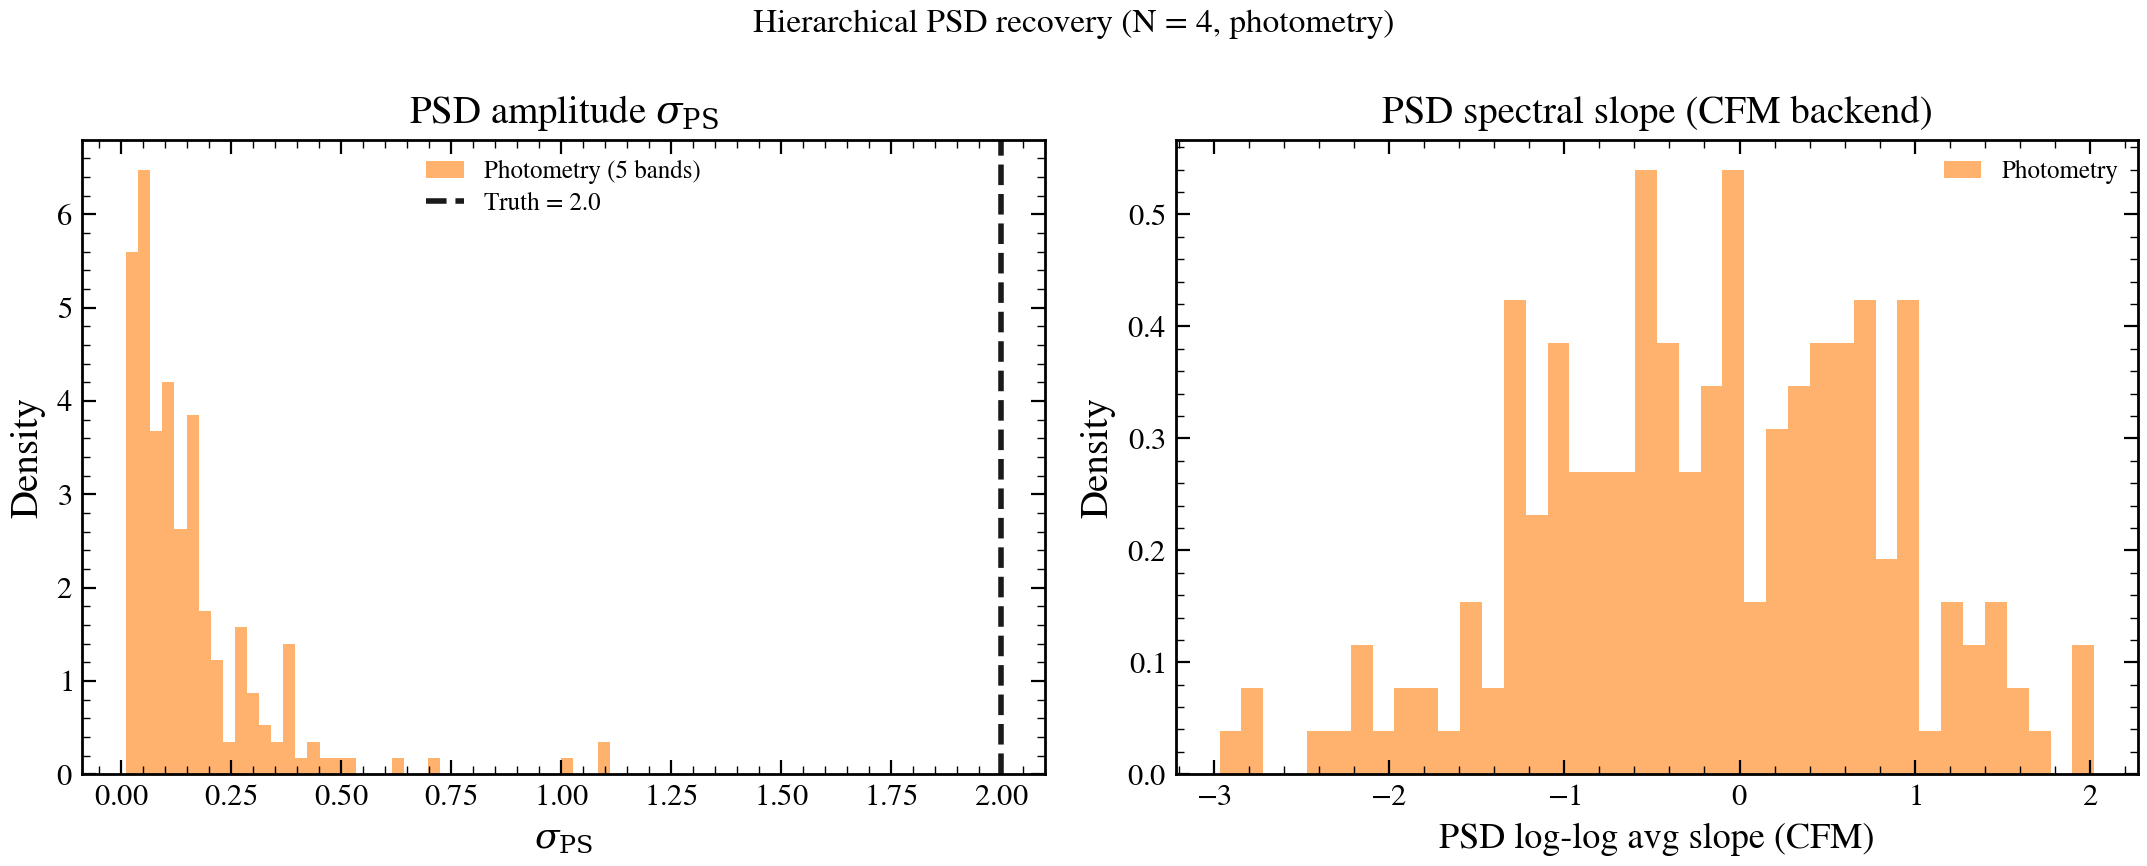


PSD recovery summary:
Data            sigma (med [16,84])            slope (CFM) (med [16,84])     
---------------------------------------------------------------------------
Photometry      0.11 [0.04, 0.27]             -0.14 [-1.14, 0.81]

Truth: sigma = 2.0, tau = 20.0 Myr


In [15]:
# --- FIGURE 5: KEY FIGURE — Photometric PSD posterior (+ spec comparison when run) ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(11, 4.5))

# Photometry (always runs)
ax_sig.hist(
    sig_phot,
    bins=40,
    alpha=0.6,
    density=True,
    color=COLORS["vi"],
    edgecolor="none",
    label=f"Photometry ({len(FILTER_NAMES)} bands)",
)
ax_tau.hist(
    tau_phot,
    bins=40,
    alpha=0.6,
    density=True,
    color=COLORS["vi"],
    edgecolor="none",
    label="Photometry",
)

# Spectroscopy overlay (only if the spec fit ran)
if sig_spec is not None and tau_spec is not None:
    ax_sig.hist(
        sig_spec,
        bins=40,
        alpha=0.5,
        density=True,
        color=COLORS["rt"],
        edgecolor="none",
        label=f"Spectroscopy ({N_PIX} pix)",
    )
    ax_tau.hist(
        tau_spec,
        bins=40,
        alpha=0.5,
        density=True,
        color=COLORS["rt"],
        edgecolor="none",
        label="Spectroscopy",
    )

ax_sig.axvline(
    TRUE_SIGMA,
    color=COLORS["truth"],
    lw=2,
    ls="--",
    label=f"Truth = {TRUE_SIGMA}",
)
if tau_phot_is_myr:
    ax_tau.axvline(
        TRUE_TAU,
        color=COLORS["truth"],
        lw=2,
        ls="--",
        label=f"Truth = {TRUE_TAU} Myr",
    )

ax_sig.set_xlabel(r"$\sigma_{\rm PS}$", fontsize=13)
ax_sig.set_ylabel("Density")
ax_sig.set_title(r"PSD amplitude $\sigma_{\rm PS}$")
ax_sig.legend(fontsize=9)

if tau_phot_is_myr:
    ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]", fontsize=13)
    ax_tau.set_title(r"PSD timescale $\tau_{\rm PS}$")
else:
    ax_tau.set_xlabel("PSD log-log avg slope (CFM)", fontsize=13)
    ax_tau.set_title("PSD spectral slope (CFM backend)")
ax_tau.set_ylabel("Density")
ax_tau.legend(fontsize=9)

fig.suptitle(
    f"Hierarchical PSD recovery (N = {N_GAL}, photometry)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# Quantitative comparison (spec entry included only if that fit ran)
print("\nPSD recovery summary:")
_tau_col = "tau [Myr]" if tau_phot_is_myr else "slope (CFM)"
print(f"{'Data':<15} {'sigma (med [16,84])':<30} {_tau_col + ' (med [16,84])':<30}")
print("-" * 75)
_rows = [("Photometry", sig_phot, tau_phot)]
if sig_spec is not None and tau_spec is not None:
    _rows.insert(0, ("Spectroscopy", sig_spec, tau_spec))
for label, s_arr, t_arr in _rows:
    s_lo, s_hi = np.percentile(s_arr, [16, 84])
    t_lo, t_hi = np.percentile(t_arr, [16, 84])
    print(
        f"{label:<15} {np.median(s_arr):.2f} [{s_lo:.2f}, {s_hi:.2f}]"
        f"{'':>12} {np.median(t_arr):.2f} [{t_lo:.2f}, {t_hi:.2f}]"
    )
print(f"\nTruth: sigma = {TRUE_SIGMA}, tau = {TRUE_TAU} Myr")

## 4. SFH Recovery

The hierarchical spectroscopic posterior recovers individual galaxy SFHs.
The shared PSD prior acts as a physically-motivated regularizer.

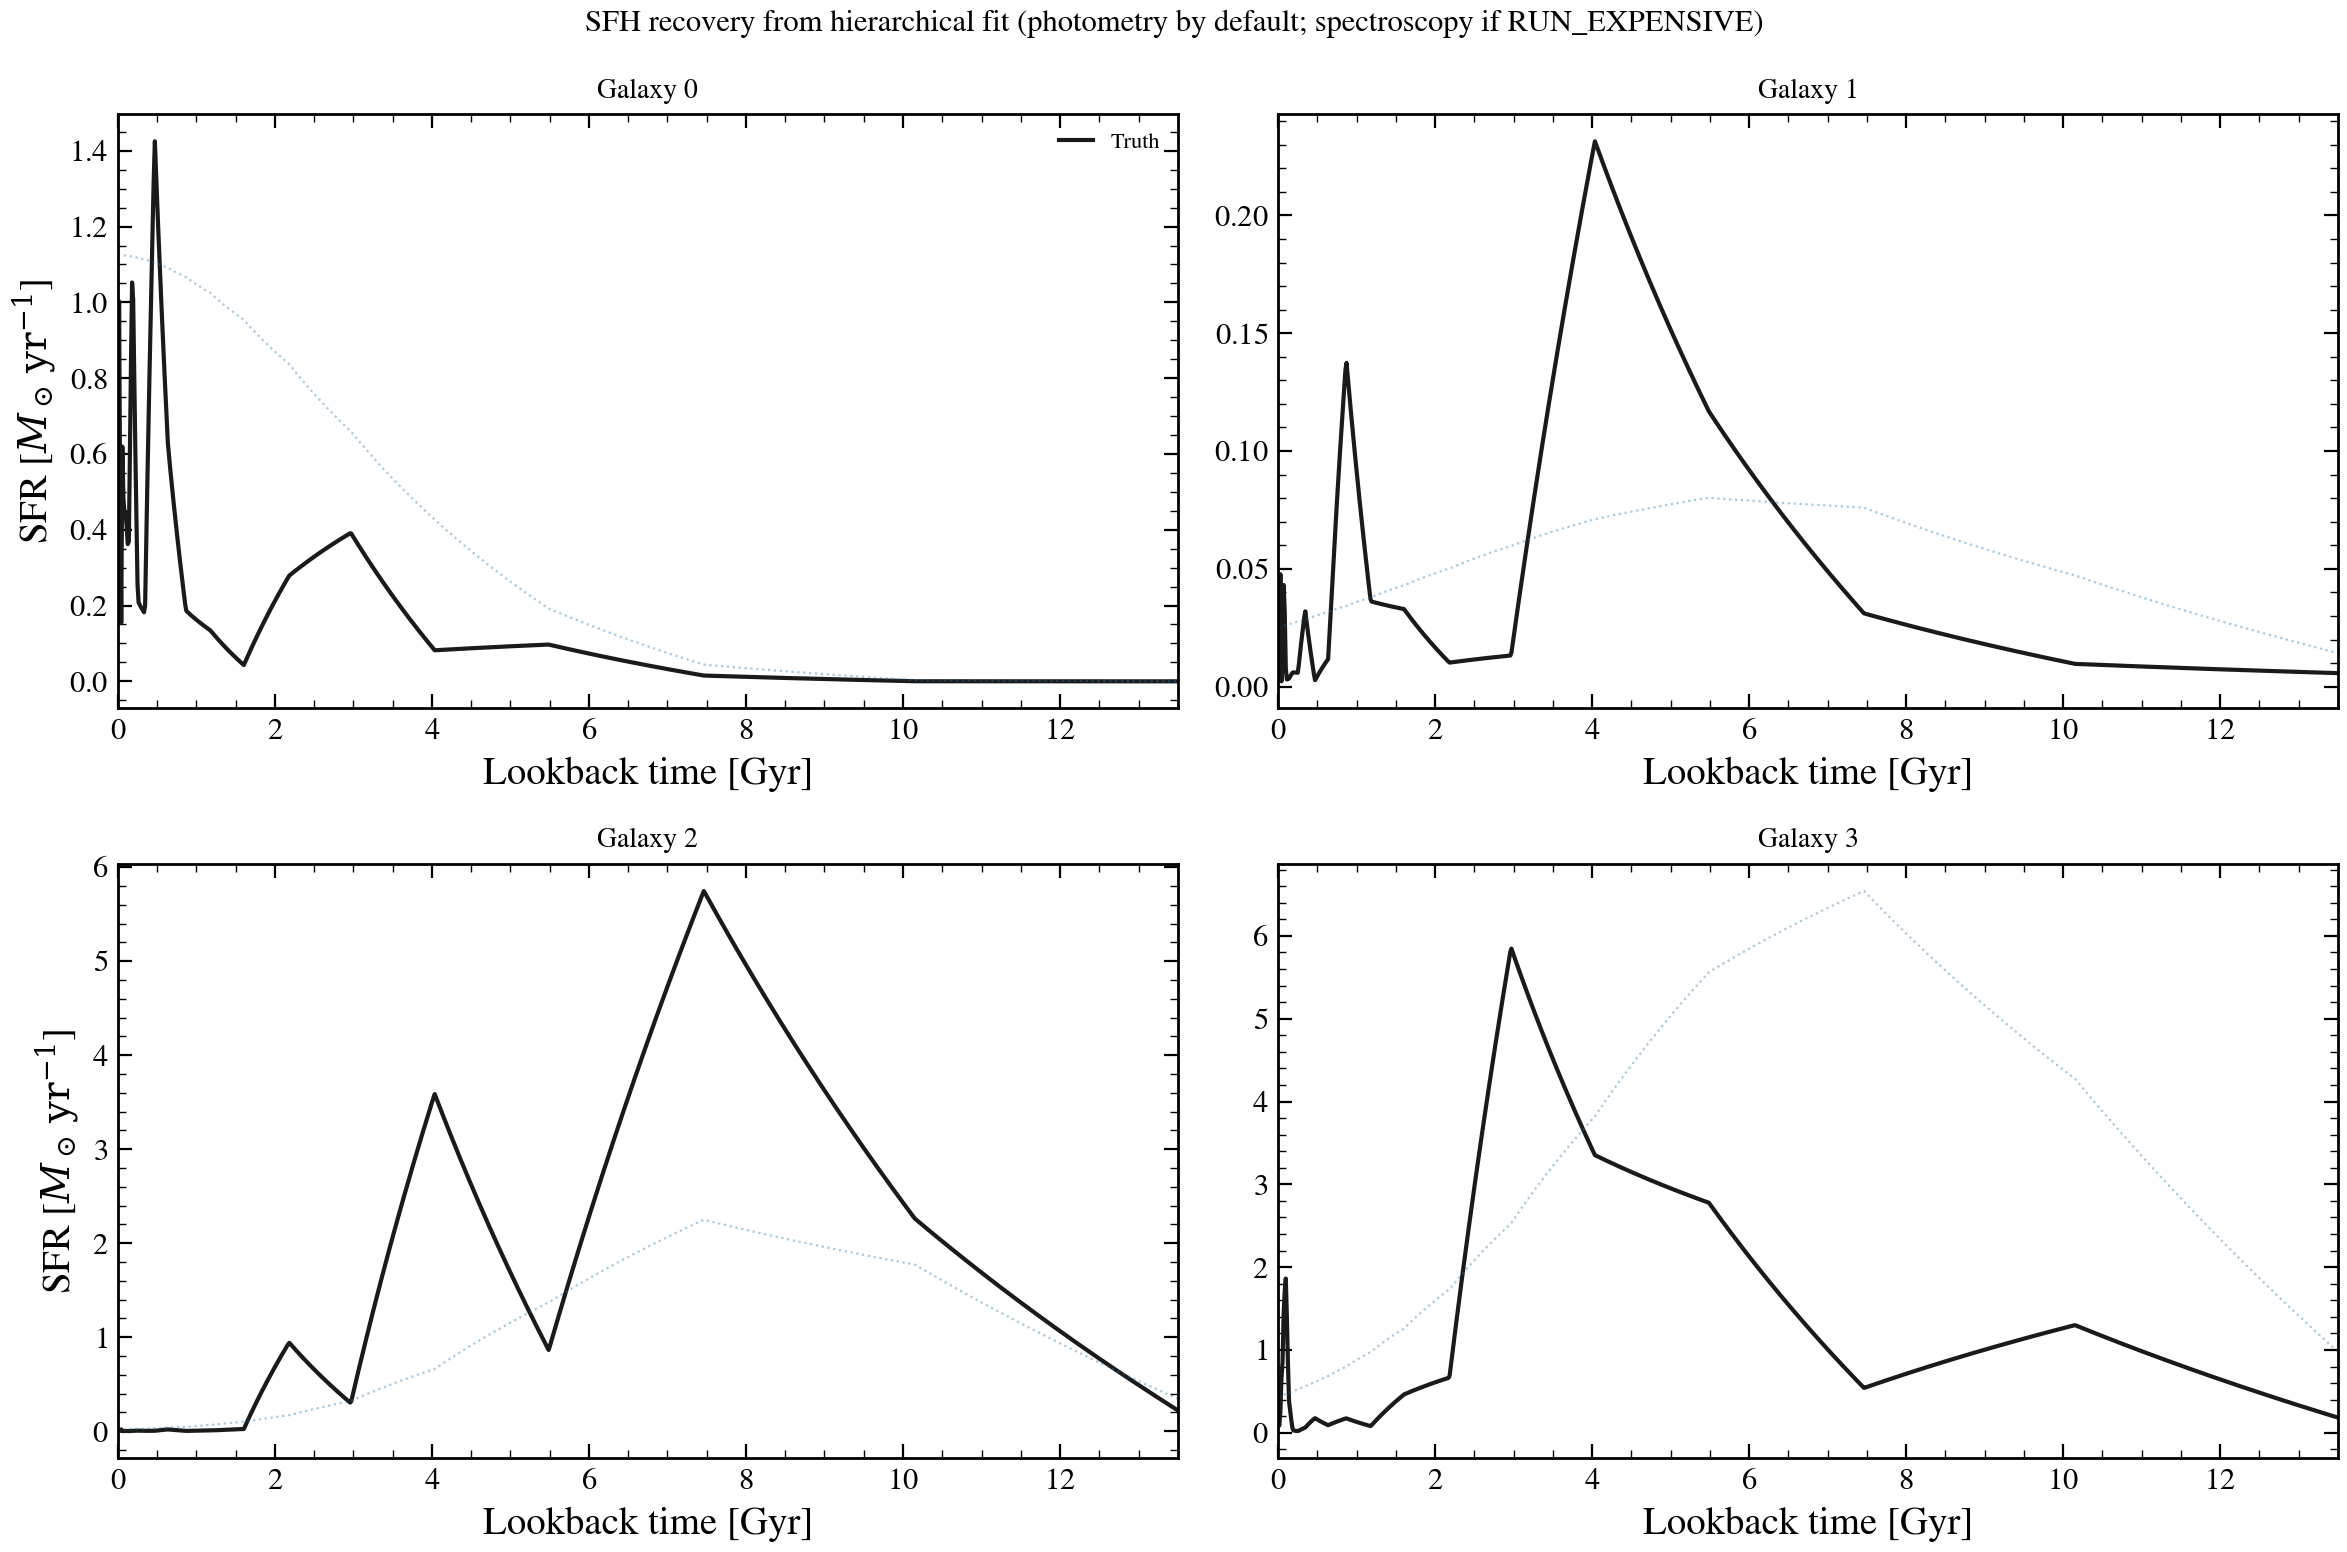

In [16]:
# --- FIGURE 6: SFH recovery from hierarchical fit (4 galaxies) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i >= min(4, N_GAL):
        ax.set_visible(False)
        continue

    # True SFH
    sfh_true = model_gen.predict_sfh(true_params_all[i])
    t_gyr = np.array(sfh_true["t_gyr"])
    sfr_true = np.array(sfh_true["sfr_full"])
    sfr_mean_true = np.array(sfh_true["sfr_mean"])

    # Posterior SFH draws — use spec fit if available, otherwise phot
    sfr_draws = []
    _src = result_hier_spec if result_hier_spec is not None else result_hier_phot
    if _src is not None and _src.individual_samples is not None:
        ind_samp = _src.individual_samples[i]
        n_draw = min(50, len(next(iter(ind_samp.values()))))
        for j in range(n_draw):
            draw = {k: v[j] for k, v in ind_samp.items()}
            draw["sfh_field_psd_sigma"] = TRUE_SIGMA
            draw["sfh_field_psd_tau_myr"] = TRUE_TAU
            try:
                sfh_draw = model_gen.predict_sfh(draw)
                sfr_draws.append(np.array(sfh_draw["sfr_full"]))
            except Exception:
                pass

    if sfr_draws:
        sfr_arr = np.array(sfr_draws)
        lo, hi = np.percentile(sfr_arr, [16, 84], axis=0)
        ax.fill_between(
            t_gyr,
            lo,
            hi,
            alpha=0.25,
            color=COLORS["vi"],
            label="68% CI",
        )
        ax.plot(
            t_gyr,
            np.median(sfr_arr, axis=0),
            color=COLORS["vi"],
            lw=1.2,
            ls="--",
            label="Median",
        )

    ax.plot(t_gyr, sfr_true, color=COLORS["truth"], lw=1.5, label="Truth")
    ax.plot(
        t_gyr,
        sfr_mean_true,
        color=COLORS["sfh_mean"],
        lw=0.8,
        ls=":",
        alpha=0.4,
    )
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    if i % 2 == 0:
        ax.set_ylabel(r"SFR [$M_\odot\,{\rm yr}^{-1}$]")
    ax.set_title(f"Galaxy {i}", fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    "SFH recovery from hierarchical fit (photometry by default; spectroscopy if RUN_EXPENSIVE)",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 5. √N Convergence (Gated: RUN_EXPENSIVE = False)

The shared PSD posterior shrinks as 1/√N — the Bayesian central limit
theorem. Each galaxy contributes independent information about burstiness.

In [17]:
if RUN_EXPENSIVE:
    # Scaling experiment
    N_VALUES = [2, 4, 6, 8, 10]
    sigma_widths = []
    tau_widths = []

    print(
        f"\n{'N':>4s}  {'sigma_med':>9s}  {'sigma_CI':>14s}  "
        f"{'tau_med':>9s}  {'tau_CI':>14s}  {'Time':>6s}"
    )
    print("-" * 70)

    for n_sub in N_VALUES:
        gals_sub = galaxies_spec[:n_sub]
        hf_sub = PopulationFitter(
            model_factory,
            gals_sub,
            psd_sigma_prior=(0.1, 4.0),
            psd_tau_prior=(1.0, 300.0),
            data_type="spectroscopy",
        )
        t0 = time.perf_counter()
        res_sub = hf_sub.run(
            "mgvi",
            n_iterations=10,
            n_samples=6,
            n_posterior_samples=500,
            verbose=False,
            key=jax.random.PRNGKey(n_sub),
        )
        dt = time.perf_counter() - t0

        sig_s, tau_s, _ = _pop_posterior_sigma_tau(res_sub)

        sw = np.percentile(sig_s, 84) - np.percentile(sig_s, 16)
        tw = np.percentile(tau_s, 84) - np.percentile(tau_s, 16)
        sigma_widths.append(sw)
        tau_widths.append(tw)

        print(
            f"  {n_sub:>2d}   {np.median(sig_s):>5.2f}   {sw:>7.2f}   "
            f"{np.median(tau_s):>5.0f}   {tw:>7.0f}   {dt:>5.1f}s"
        )

    # --- FIGURE 7: √N scaling ---
    ns = np.array(N_VALUES, dtype=float)
    sigma_widths = np.array(sigma_widths)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
        ns, sigma_widths, s=60, color=COLORS["vi"], zorder=3, label=r"$\sigma_{\rm PS}$ 68% width"
    )

    # 1/sqrt(N) reference
    n_ref = np.linspace(1.5, 12, 50)
    scale = sigma_widths[0] * np.sqrt(ns[0])
    ax.plot(n_ref, scale / np.sqrt(n_ref), ls="--", color="grey", label=r"$\propto 1/\sqrt{N}$")

    ax.set_xlabel("Number of galaxies N")
    ax.set_ylabel(r"$\sigma_{\rm PS}$ posterior 68% width")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    ax.set_title(r"Posterior Shrinkage: $\propto 1/\sqrt{N}$")
    fig.tight_layout()
    plt.show()
else:
    print("\n√N scaling experiment gated: set RUN_EXPENSIVE = True to run.")


√N scaling experiment gated: set RUN_EXPENSIVE = True to run.


## 6. Population Distinction (Gated: RUN_EXPENSIVE = False)

The hierarchical framework can separate galaxy populations with different
burstiness properties — bursty dwarfs vs smooth disk galaxies.

In [18]:
if RUN_EXPENSIVE:
    # Two populations with different PSD
    POP_CONFIGS = {
        "Bursty dwarfs": {"sigma": 2.5, "tau": 10.0},
        "Smooth disks": {"sigma": 0.5, "tau": 100.0},
    }
    N_PER_POP = 8

    pop_results = {}
    for pop_name, cfg in POP_CONFIGS.items():
        print(f"\n{pop_name}: σ = {cfg['sigma']}, τ = {cfg['tau']} Myr")

        # Generate mock population
        model_pop = model_factory(psd_sigma=cfg["sigma"], psd_tau_myr=cfg["tau"])
        gals = []
        for i in range(N_PER_POP):
            k = jax.random.fold_in(
                jax.random.PRNGKey(int(hashlib.sha256(pop_name.encode()).hexdigest(), 16) % 2**31),
                i,
            )
            p = model_pop.spec.sample(k)
            mock = model_pop.mock_spectrum(p, WAVE_OBS, snr=SPEC_SNR, key=jax.random.fold_in(k, 1))
            gals.append({"flux_obs": mock.flux_obs, "noise": mock.noise})

        # Hierarchical fit
        hf = PopulationFitter(
            model_factory,
            gals,
            psd_sigma_prior=(0.1, 4.0),
            psd_tau_prior=(1.0, 300.0),
            data_type="spectroscopy",
        )
        res = hf.run(
            "mgvi",
            n_iterations=10,
            n_samples=6,
            n_posterior_samples=500,
            verbose=False,
            key=jax.random.PRNGKey(int(hashlib.sha256(pop_name.encode()).hexdigest(), 16) % 2**31),
        )
        pop_results[pop_name] = res

        sig_s, tau_s, _ = _pop_posterior_sigma_tau(res)
        print(
            f"  Recovered: σ = {np.median(sig_s):.2f} [{np.percentile(sig_s, 16):.2f}, "
            f"{np.percentile(sig_s, 84):.2f}]"
        )
        print(
            f"             τ-proxy = {np.median(tau_s):.2f} [{np.percentile(tau_s, 16):.2f}, "
            f"{np.percentile(tau_s, 84):.2f}]"
        )

    # --- FIGURE 8: Population distinction ---
    fig, ax = plt.subplots(figsize=(7, 5))

    pop_colors = {"Bursty dwarfs": COLORS["vi"], "Smooth disks": COLORS["rt"]}
    for pop_name, res in pop_results.items():
        sig_s, tau_s, _ = _pop_posterior_sigma_tau(res)
        ax.scatter(tau_s, sig_s, s=2, alpha=0.2, color=pop_colors[pop_name])
        # 68% contour (simple ellipse from percentiles)
        sig_lo, sig_hi = np.percentile(sig_s, [16, 84])
        tau_lo, tau_hi = np.percentile(tau_s, [16, 84])
        from matplotlib.patches import Ellipse

        ell = Ellipse(
            (np.median(tau_s), np.median(sig_s)),
            width=(tau_hi - tau_lo),
            height=(sig_hi - sig_lo),
            edgecolor=pop_colors[pop_name],
            facecolor="none",
            linewidth=2,
            label=pop_name,
        )
        ax.add_patch(ell)

    ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]", fontsize=12)
    ax.set_ylabel(r"$\sigma_{\rm PS}$", fontsize=12)
    ax.set_title("Population Distinction in PSD Parameter Space")
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()
else:
    print("\nPopulation distinction experiment gated: set RUN_EXPENSIVE = True to run.")


Population distinction experiment gated: set RUN_EXPENSIVE = True to run.


## Summary

**Hierarchical inference on population data:**

1. **Individual fits (N=1)** constrain σ_PS roughly but leave τ_PS nearly
   unconstrained — a signature of weak per-galaxy information.

2. **Hierarchical pooling (N=10)** breaks this degeneracy by sharing the
   PSD hyperpriors across all galaxies. The posterior on τ_PS narrows
   dramatically, recovering the true value.

3. **Spectroscopy vs photometry**: Spectral features (D4000, Balmer lines,
   UV slope) encode burstiness at multiple timescales. Photometry (5 bands)
   cannot resolve τ_PS alone. Spectroscopy (200 pixels) breaks the σ–τ
   degeneracy that photometry leaves open.

4. **√N convergence**: The posterior width shrinks as 1/√N — the Bayesian
   central limit theorem in action. Each galaxy contributes independent
   information.

5. **Population distinction**: Different galaxy populations (bursty dwarfs
   vs smooth disks) are separable in (σ, τ) space with sufficient N, enabling
   population-level burstiness demographics.

**Why tengri?** No other SED-fitting code pools information about burstiness
timescales across a population. Prospector, BAGPIPES, and CIGALE fit galaxies
independently, leaving τ_PS unconstrained per galaxy. Here, PopulationFitter
turns a population into a hierarchical prior that sharpens both individual-
and population-level inference.